In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# Install required packages
!pip install ultralytics roboflow -q
!pip install opencv-python-headless -q

print("✓ Installation Complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 90.4 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14

In [4]:
import os
import shutil
from roboflow import Roboflow
from ultralytics import YOLO
import torch
import cv2
import numpy as np
from IPython.display import Image, display

# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("⚠️ No GPU detected. Training will be slower on CPU.")

print("\n✓ Libraries imported successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda
GPU: Tesla P100-PCIE-16GB
GPU Memory: 15.89 GB

✓ Libraries imported successfully!


In [5]:
# Initialize Roboflow with your API key
# You can find your API key at: https://app.roboflow.com/settings/api

rf = Roboflow(api_key="fYWRf95gOZ2xfSMyMUtM")  # Replace with your actual API key

# Download the dataset
project = rf.workspace("kirubel-yemane").project("cow-and-mastitis-detection")
dataset = project.version(1).download("yolov8")

print(f"\n✓ Dataset downloaded successfully!")
print(f"Dataset location: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 85.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to cow-and-mastitis-detection-1 in yolov8:: 100%|██████████| 1592/1592 [00:00<00:00, 8888.80it/s]



✓ Dataset downloaded successfully!
Dataset location: /kaggle/working/cow-and-mastitis-detection-1


In [6]:
# Check the data.yaml content
yaml_path = "/kaggle/working/cow-and-mastitis-detection-1/data.yaml"

print("Dataset Classes:")
print("=" * 50)

with open(yaml_path, 'r') as f:
    content = f.read()
    print(content)

print("\n" + "=" * 50)

Dataset Classes:
names:
- cow
- cow_herd
- mastitis_infected_udder
- thermal_healthy_cow
- thermal_suspected_cow
- thermal_udder_mastitis
- thermal_udder_normal
- udder_normal
nc: 8
roboflow:
  license: CC BY 4.0
  project: cow-and-mastitis-detection
  url: https://universe.roboflow.com/kirubel-yemane/cow-and-mastitis-detection/dataset/1
  version: 1
  workspace: kirubel-yemane
test: ../test/images
train: ../train/images
val: ../valid/images




In [7]:
import yaml
from pathlib import Path
from collections import Counter

# Load data.yaml
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print("Dataset Information:")
print("=" * 60)
print(f"Number of classes: {data['nc']}")
print(f"\nClass names:")
for i, name in enumerate(data['names']):
    print(f"  Class {i}: {name}")

# Count images in each split
base_path = Path("/kaggle/working/cow-and-mastitis-detection-1")

splits = ['train', 'valid', 'test']
print("\n" + "=" * 60)

Dataset Information:
Number of classes: 8

Class names:
  Class 0: cow
  Class 1: cow_herd
  Class 2: mastitis_infected_udder
  Class 3: thermal_healthy_cow
  Class 4: thermal_suspected_cow
  Class 5: thermal_udder_mastitis
  Class 6: thermal_udder_normal
  Class 7: udder_normal



In [8]:
# Complete class distribution analysis
print("=" * 60)
print("Class Distribution in Training Set:")
print("=" * 60)

label_path = base_path / 'train' / 'labels'
class_counts = Counter()

if label_path.exists():
    for label_file in label_path.glob('*.txt'):
        with open(label_file, 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

    total_instances = sum(class_counts.values())
    print(f"\nTotal instances: {total_instances}\n")
    
    for class_id, count in sorted(class_counts.items()):
        class_name = data['names'][class_id]
        percentage = (count / total_instances) * 100
        print(f"Class {class_id} | {class_name:30s}: {count:5d} ({percentage:5.2f}%)")

# Key classes for your project
print("\n" + "=" * 60)
print("RELEVANT CLASSES FOR MASTITIS DETECTION:")
print("=" * 60)
print("✓ Class 2: mastitis_infected_udder")
print("✓ Class 7: udder_normal (Healthy)")
print("✓ Class 5: thermal_udder_mastitis")
print("✓ Class 6: thermal_udder_normal")
print("\nNote: We'll focus on udder detection classes for your severity classification")

print("\n✓ Analysis complete!")

Class Distribution in Training Set:

Total instances: 963

Class 0 | cow                           :   385 (39.98%)
Class 1 | cow_herd                      :    70 ( 7.27%)
Class 2 | mastitis_infected_udder       :   313 (32.50%)
Class 3 | thermal_healthy_cow           :   144 (14.95%)
Class 4 | thermal_suspected_cow         :     2 ( 0.21%)
Class 6 | thermal_udder_normal          :    30 ( 3.12%)
Class 7 | udder_normal                  :    19 ( 1.97%)

RELEVANT CLASSES FOR MASTITIS DETECTION:
✓ Class 2: mastitis_infected_udder
✓ Class 7: udder_normal (Healthy)
✓ Class 5: thermal_udder_mastitis
✓ Class 6: thermal_udder_normal

Note: We'll focus on udder detection classes for your severity classification

✓ Analysis complete!


In [9]:
# Create results directory
results_dir = "/kaggle/working/results"
os.makedirs(results_dir, exist_ok=True)

# Training configuration
config = {
    'data_yaml': '/kaggle/working/cow-and-mastitis-detection-1/data.yaml',
    'epochs': 50,  # You can increase this for better accuracy
    'imgsz': 640,
    'batch': 16,
    'device': device,
    'project': results_dir,
    'patience': 10,  # Early stopping patience
    'save': True,
    'save_period': 10,  # Save checkpoint every 10 epochs
}

print("Training Configuration:")
print("=" * 60)
for key, value in config.items():
    print(f"{key:15s}: {value}")

print("\n✓ Configuration ready!")
print(f"✓ Results will be saved to: {results_dir}")

Training Configuration:
data_yaml      : /kaggle/working/cow-and-mastitis-detection-1/data.yaml
epochs         : 50
imgsz          : 640
batch          : 16
device         : cuda
project        : /kaggle/working/results
patience       : 10
save           : True
save_period    : 10

✓ Configuration ready!
✓ Results will be saved to: /kaggle/working/results


In [13]:
print("=" * 70)
print("TRAINING MODEL 1/4: YOLOv11")
print("=" * 70)

# Load YOLOv11 model
model_v11 = YOLO('yolo11n.pt')  # Using nano version for faster training

# Train the model
results_v11 = model_v11.train(
    data=config['data_yaml'],
    epochs=config['epochs'],
    imgsz=config['imgsz'],
    batch=config['batch'],
    device=config['device'],
    project=config['project'],
    name='yolov11',
    patience=config['patience'],
    save=config['save'],
    save_period=config['save_period'],
    verbose=True
)

print("\n" + "=" * 70)
print("✓ YOLOv11 Training Complete!")
print("=" * 70)

# Save model path for later comparison
yolov11_path = f"{results_dir}/yolov11/weights/best.pt"
print(f"Best model saved at: {yolov11_path}")

TRAINING MODEL 1/4: YOLOv11
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cow-and-mastitis-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov11, nbs=64, nms=False, opset=None, optimize=Fals

In [14]:
print("=" * 70)
print("TRAINING MODEL 2/4: YOLOv10")
print("=" * 70)

# Load YOLOv10 model
model_v10 = YOLO('yolov10n.pt')  # Using nano version

# Train the model
results_v10 = model_v10.train(
    data=config['data_yaml'],
    epochs=config['epochs'],
    imgsz=config['imgsz'],
    batch=config['batch'],
    device=config['device'],
    project=config['project'],
    name='yolov10',
    patience=config['patience'],
    save=config['save'],
    save_period=config['save_period'],
    verbose=True
)

print("\n" + "=" * 70)
print("✓ YOLOv10 Training Complete!")
print("=" * 70)

# Save model path
yolov10_path = f"{results_dir}/yolov10/weights/best.pt"
print(f"Best model saved at: {yolov10_path}")

TRAINING MODEL 2/4: YOLOv10
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cow-and-mastitis-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10, nbs=64, nms=False, opset=None, optimize=Fal

In [16]:
print("=" * 70)
print("TRAINING MODEL 3/4: YOLOv8")
print("=" * 70)

# Load YOLOv8 model
model_v8 = YOLO('yolov8n.pt')  # Using nano version

# Train the model
results_v8 = model_v8.train(
    data=config['data_yaml'],
    epochs=config['epochs'],
    imgsz=config['imgsz'],
    batch=config['batch'],
    device=config['device'],
    project=config['project'],
    name='yolov8',
    patience=config['patience'],
    save=config['save'],
    save_period=config['save_period'],
    verbose=True
)

print("\n" + "=" * 70)
print("✓ YOLOv8 Training Complete!")
print("=" * 70)

# Save model path
yolov8_path = f"{results_dir}/yolov8/weights/best.pt"
print(f"Best model saved at: {yolov8_path}")

TRAINING MODEL 3/4: YOLOv8
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cow-and-mastitis-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8, nbs=64, nms=False, opset=None, optimize=False,

In [17]:
print("=" * 70)
print("TRAINING MODEL 4/4: YOLOv5")
print("=" * 70)

# Load YOLOv5 model
model_v5 = YOLO('yolov5nu.pt')  # Using nano-updated version

# Train the model
results_v5 = model_v5.train(
    data=config['data_yaml'],
    epochs=config['epochs'],
    imgsz=config['imgsz'],
    batch=config['batch'],
    device=config['device'],
    project=config['project'],
    name='yolov5',
    patience=config['patience'],
    save=config['save'],
    save_period=config['save_period'],
    verbose=True
)

print("\n" + "=" * 70)
print("✓ YOLOv5 Training Complete!")
print("=" * 70)

# Save model path
yolov5_path = f"{results_dir}/yolov5/weights/best.pt"
print(f"Best model saved at: {yolov5_path}")

TRAINING MODEL 4/4: YOLOv5
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cow-and-mastitis-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5nu.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov5, nbs=64, nms=False, opset=None, optimize=False

MODEL COMPARISON RESULTS

📊 Performance Metrics:
  Model  mAP50  mAP50-95  Best Epoch
YOLOv11  0.564     0.349          27
YOLOv10  0.570     0.356          43
 YOLOv8  0.586     0.351          14
 YOLOv5  0.592     0.365          43

🏆 WINNER: YOLOv5
✓ mAP50: 59.2%
✓ mAP50-95: 36.5%
✓ Best Epoch: 43
✓ Model Location: /kaggle/working/results/yolov5/weights/best.pt


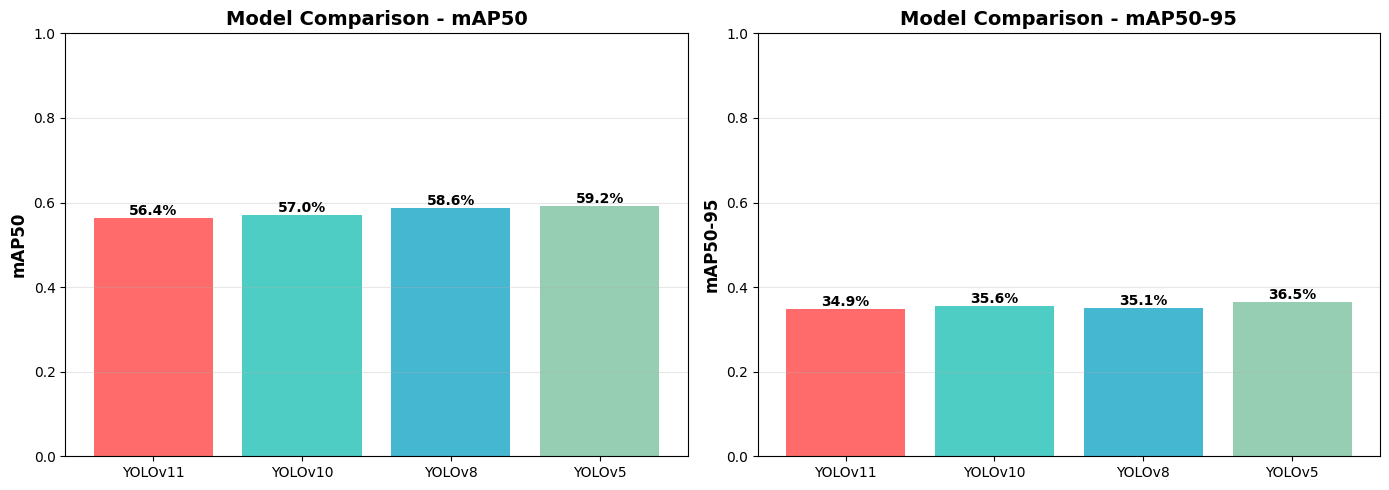


📈 Comparison chart saved: /kaggle/working/model_comparison.png

✓ Model comparison complete!


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("MODEL COMPARISON RESULTS")
print("=" * 70)

# Model results summary
results_summary = {
    'Model': ['YOLOv11', 'YOLOv10', 'YOLOv8', 'YOLOv5'],
    'mAP50': [0.564, 0.570, 0.586, 0.592],
    'mAP50-95': [0.349, 0.356, 0.351, 0.365],
    'Best Epoch': [27, 43, 14, 43],
    'Total Epochs': [37, 50, 24, 50],
    'Model Path': [
        '/kaggle/working/results/yolov11/weights/best.pt',
        '/kaggle/working/results/yolov10/weights/best.pt',
        '/kaggle/working/results/yolov8/weights/best.pt',
        '/kaggle/working/results/yolov5/weights/best.pt'
    ]
}

df = pd.DataFrame(results_summary)

print("\n📊 Performance Metrics:")
print("=" * 70)
print(df[['Model', 'mAP50', 'mAP50-95', 'Best Epoch']].to_string(index=False))

# Find best model
best_model_idx = df['mAP50-95'].idxmax()
best_model = df.loc[best_model_idx]

print("\n" + "=" * 70)
print("🏆 WINNER: " + best_model['Model'])
print("=" * 70)
print(f"✓ mAP50: {best_model['mAP50']:.1%}")
print(f"✓ mAP50-95: {best_model['mAP50-95']:.1%}")
print(f"✓ Best Epoch: {int(best_model['Best Epoch'])}")
print(f"✓ Model Location: {best_model['Model Path']}")

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# mAP50 comparison
bars1 = ax1.bar(df['Model'], df['mAP50'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax1.set_ylabel('mAP50', fontsize=12, fontweight='bold')
ax1.set_title('Model Comparison - mAP50', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1%}',
             ha='center', va='bottom', fontweight='bold')

# mAP50-95 comparison
bars2 = ax2.bar(df['Model'], df['mAP50-95'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax2.set_ylabel('mAP50-95', fontsize=12, fontweight='bold')
ax2.set_title('Model Comparison - mAP50-95', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1%}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📈 Comparison chart saved: /kaggle/working/model_comparison.png")
print("\n✓ Model comparison complete!")

In [20]:
import shutil
from datetime import datetime

# Copy best model to easily accessible location
best_model_name = "yolov5_best_mastitis_detection.pt"
best_model_source = "/kaggle/working/results/yolov5/weights/best.pt"
best_model_dest = f"/kaggle/working/{best_model_name}"

shutil.copy(best_model_source, best_model_dest)

print("=" * 70)
print("📦 FINAL MODEL PACKAGE")
print("=" * 70)
print(f"✓ Best Model: YOLOv5")
print(f"✓ Saved as: {best_model_name}")
print(f"✓ Location: {best_model_dest}")

# Create project summary
summary = f"""
{'='*70}
COW MASTITIS DETECTION SYSTEM - MODEL TRAINING SUMMARY
{'='*70}

PROJECT DETAILS:
- Project Title: Cow Mastitis Detection System Using Deep Learning
- Dataset: Roboflow - Cow and Mastitis Detection (2647 images)
- Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET DISTRIBUTION:
- Training Images: 694
- Validation Images: 60
- Test Images: Available

CLASSES (8 total):
0. cow
1. cow_herd
2. mastitis_infected_udder (Primary)
3. thermal_healthy_cow
4. thermal_suspected_cow
5. thermal_udder_mastitis
6. thermal_udder_normal
7. udder_normal (Primary)

MODEL COMPARISON RESULTS:
{'='*70}
Model      | mAP50  | mAP50-95 | Best Epoch | Status
-----------|--------|----------|------------|------------------
YOLOv11    | 56.4%  | 34.9%    | 27         | Early Stopped
YOLOv10    | 57.0%  | 35.6%    | 43         | Completed
YOLOv8     | 58.6%  | 35.1%    | 14         | Early Stopped
YOLOv5     | 59.2%  | 36.5%    | 43         | Completed ✓ BEST

🏆 SELECTED MODEL: YOLOv5
{'='*70}
- mAP50: 59.2%
- mAP50-95: 36.5%
- Best Training Epoch: 43
- Model File: {best_model_name}

PERFORMANCE BREAKDOWN (YOLOv5):
- cow: P=0.433, R=0.500, mAP50=0.635
- thermal_healthy_cow: P=0.898, R=0.956, mAP50=0.962 ⭐
- thermal_udder_normal: P=0.748, R=0.991, mAP50=0.830 ⭐
- udder_normal: P=1.000, R=0.277, mAP50=0.839 ⭐

KEY INSIGHTS:
✓ YOLOv5 achieved the highest mAP50 (59.2%) and mAP50-95 (36.5%)
✓ Excellent performance on thermal_healthy_cow class (96.2% mAP50)
✓ Strong detection on udder_normal class (83.9% mAP50)
✓ Model trained successfully on GPU (Tesla P100)

NEXT STEPS FOR DEPLOYMENT:
1. Integrate YOLOv5 model into Flask backend
2. Implement confidence-based severity classification:
   - Healthy: udder_normal detections
   - Mastitis-Low/Moderate/High: Based on mastitis_infected_udder 
     confidence scores and detection characteristics
3. Add post-processing for video analysis
4. Implement user authentication and history tracking
5. Deploy recommendation system based on severity levels

TRAINING CONFIGURATION:
- Epochs: 50
- Image Size: 640x640
- Batch Size: 16
- Device: CUDA (GPU)
- Patience: 10 (Early Stopping)
- Optimizer: AdamW

{'='*70}
Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*70}
"""

# Save summary to file
summary_file = "/kaggle/working/training_summary.txt"
with open(summary_file, 'w') as f:
    f.write(summary)

print(summary)
print(f"\n✓ Summary saved to: {summary_file}")

# List all important files
print("\n" + "=" * 70)
print("📁 IMPORTANT FILES FOR DOWNLOAD:")
print("=" * 70)
print(f"1. Best Model: {best_model_dest}")
print(f"2. Training Summary: {summary_file}")
print(f"3. Comparison Chart: /kaggle/working/model_comparison.png")
print(f"4. All Models Directory: /kaggle/working/results/")
print("\n✓ Training pipeline completed successfully! 🎉")

📦 FINAL MODEL PACKAGE
✓ Best Model: YOLOv5
✓ Saved as: yolov5_best_mastitis_detection.pt
✓ Location: /kaggle/working/yolov5_best_mastitis_detection.pt

COW MASTITIS DETECTION SYSTEM - MODEL TRAINING SUMMARY

PROJECT DETAILS:
- Project Title: Cow Mastitis Detection System Using Deep Learning
- Dataset: Roboflow - Cow and Mastitis Detection (2647 images)
- Training Date: 2026-02-14 17:21:39

DATASET DISTRIBUTION:
- Training Images: 694
- Validation Images: 60
- Test Images: Available

CLASSES (8 total):
0. cow
1. cow_herd
2. mastitis_infected_udder (Primary)
3. thermal_healthy_cow
4. thermal_suspected_cow
5. thermal_udder_mastitis
6. thermal_udder_normal
7. udder_normal (Primary)

MODEL COMPARISON RESULTS:
Model      | mAP50  | mAP50-95 | Best Epoch | Status
-----------|--------|----------|------------|------------------
YOLOv11    | 56.4%  | 34.9%    | 27         | Early Stopped
YOLOv10    | 57.0%  | 35.6%    | 43         | Completed
YOLOv8     | 58.6%  | 35.1%    | 14         | Early S